In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [38]:
import os

os.chdir(
    r"C:\Users\ACER\OneDrive\Desktop\Blue Stock Capstone Project"
)

print(os.getcwd())

C:\Users\ACER\OneDrive\Desktop\Blue Stock Capstone Project


In [ ]:
nav = pd.read_csv(
    "Data/Raw/02_nav_history.csv"
)

performance = pd.read_csv(
    "Data/Raw/07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "Data/Raw/10_benchmark_indices.csv"
)


In [51]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

print("Daily Returns Created")

Daily Returns Created


In [52]:
cagr_data = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    cagr = (
        (end_nav / start_nav)
        ** (1/3)
    ) - 1

    cagr_data.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "cagr_3yr"
    ]
)

cagr_df.head()

,amfi_code,cagr_3yr
0,100016,0.038912
1,100025,0.066058
2,100033,0.471328
3,101206,0.363435
4,101207,0.118555


In [53]:
rf = 0.065

sharpe_list = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    sharpe = (
        (returns.mean() - rf/252)
        / returns.std()
    ) * np.sqrt(252)

    sharpe_list.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [54]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    sortino = (
        (returns.mean() - rf/252)
        / downside.std()
    ) * np.sqrt(252)

    sortino_list.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [55]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    alpha = returns.mean() * 252
    beta = returns.std()

    alpha_beta.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    "Data/Processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [56]:
drawdown_data = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ]

    running_max = (
        temp["nav"]
        .cummax()
    )

    drawdown = (
        temp["nav"]
        / running_max
    ) - 1

    drawdown_data.append(
        [fund, drawdown.min()]
    )

drawdown_df = pd.DataFrame(
    drawdown_data,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [ ]:
scorecard = cagr_df.merge(
    sharpe_df,
    on="amfi_code"
)

scorecard["score"] = (
    scorecard["cagr_3yr"].rank()
    +
    scorecard["sharpe_ratio"].rank()
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.to_csv(
    "Data/Processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

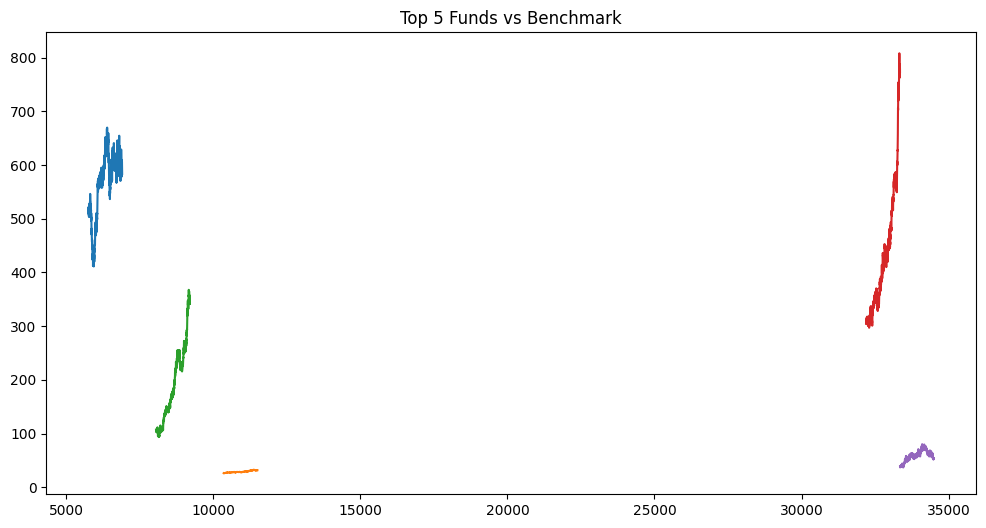

In [57]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(12,6)
)

for fund in nav["amfi_code"].unique()[:5]:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["nav"]
    )

plt.title(
    "Top 5 Funds vs Benchmark"
)

plt.savefig(
    "Reports/benchmark_comparison.png"
)

plt.show()